**Link al repositorio de GitHub:** [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo)

# CC3104 - Aprendizaje por Refuerzo
## Laboratorio 7 - Entrega Total

***
### Task 1: Análisis Crítico de Detección de Intrusiones

#### Task 1.1: Análisis de DQN Estándar
**a. Arquitectura de Red para Estado Continuo:**
DQN es arquitecturalmente **completamente apropiado** para estados continuos de alta dimensión (es exactamente para lo que fue diseñado, superando los límites de Q-Learning tabular). Dado que el estado es un vector numérico de 256 dimensiones y no una cuadrícula espacial (como los píxeles de una imagen), usaríamos un **Perceptrón Multicapa (MLP)** o red neuronal completamente conectada (Fully Connected). Una CNN sería inapropiada porque no hay invariancia espacial en un vector de logs y métricas, mientras que un MLP con capas Densas (Linear) y activación ReLU puede extraer eficazmente las combinaciones no lineales de esas 256 variables.

**b. Espacio de Acciones Discretas:**
DQN es el algoritmo ideal para esto. Su diseño original asume un espacio de acciones discreto y de baja dimensionalidad. La red neuronal toma el estado como entrada y produce 4 neuronas en su capa de salida, donde cada neurona representa el valor Q de una de las 4 acciones (ignorar, alertar, bloquear, aislar). Si el espacio fuera continuo, necesitaríamos DDPG o SAC, pero para 4 opciones discretas, DQN estándar o sus variantes son perfectos.

**c. Rareza de Eventos y Experience Replay:**
Si las intrusiones ocurren en $<0.1\%$ de los casos, la distribución de muestreo uniforme del *Experience Replay* estándar extraerá casi exclusivamente eventos de tráfico benigno. El agente sufrirá de un desbalance masivo de clases y nunca aprenderá a reaccionar a los ataques porque casi nunca los repasa en sus minibatches. 
La variante que resuelve esto es **Prioritized Experience Replay (PER)**. PER asigna una prioridad de muestreo proporcional a la magnitud del Error TD. Como una intrusión inesperada generará un gran error de predicción inicial, PER priorizará muestrear esas transiciones críticas de la memoria mucho más seguido que el tráfico aburrido y predecible, forzando a la red a aprender de sus errores en ataques reales.

**d. Diseño de Función de Recompensa Segura:**
Si minimizamos *únicamente* los falsos positivos, el agente aprenderá un comportamiento indeseable fatal: **ignorar todo el tráfico siempre**. Al no bloquear ni alertar nunca, logrará $0\%$ de falsos positivos, pero a costa de un $100\%$ de falsos negativos (dejando pasar todos los ataques).
*Función de recompensa propuesta:*
1. $+10$ por Bloquear/Aislar correctamente una intrusión real (Recompensa principal por cumplir el objetivo).
2. $-100$ por Ignorar una intrusión real (Falso Negativo: Penalidad catastrófica porque compromete la red de la empresa).
3. $-5$ por Bloquear/Aislar tráfico benigno (Falso Positivo: Penalidad moderada porque interrumpe la operatividad de un usuario, pero no destruye la empresa).
*Justificación:* El castigo de -100 obliga al agente a estar paranoico ante ataques, mientras que el -5 evita que bloquee a lo loco.

#### Task 1.2: Double DQN y la Sobreestimación
**a. El problema y su consecuencia operacional:**
DQN estándar usa el operador `max` sobre estimaciones de Q ruidosas para actualizarse, lo que matemáticamente garantiza una **sobreestimación sistemática** del verdadero valor de los estados. 
*   Si el agente sobreestima crónicamente el valor de la acción "bloquear", empezará a ejecutar bloqueos preventivos todo el tiempo, causando una Denegación de Servicio (DoS) autoinfligida en la red corporativa al cortar tráfico legítimo.
*   Si sobreestima "ignorar", dejará pasar malware asumiendo erróneamente que la red estará a salvo, resultando en brechas de datos.

**b. Expresiones del Target:**
*   **DQN Estándar:** $Y_t^{DQN} = R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a; \theta_{target})$
*   **Double DQN:** $Y_t^{DDQN} = R_{t+1} + \gamma Q(S_{t+1}, \arg\max_{a} Q(S_{t+1}, a; \theta_{online}); \theta_{target})$
*   *Único cambio de implementación:* En DDQN, usamos la red principal (online) para **seleccionar** cuál es la mejor acción en el estado siguiente, pero usamos la red objetivo (target) para **evaluar** matemáticamente cuánto vale esa acción. Esto desacopla selección y evaluación, eliminando el sesgo de maximización.

**c. Gravedad según el tipo de estado:**
La sobreestimación es un problema **muchísimo más grave en estados de alta ambigüedad (tráfico borderline)**. En estos estados, los valores reales de "ignorar" y "bloquear" son muy cercanos. Cualquier ruido estadístico en la red neuronal hará que una acción parezca ligeramente mejor y el operador `max` la seleccionará prematuramente, inflando el valor. En estados claramente maliciosos, el valor de "bloquear" está tan alejado del resto que el ruido no afecta qué acción gana el `max`, minimizando el impacto del sesgo.

***
### Task 2: Implementación Final en LunarLander

#### Task 2.1: Implementación de DQN y Double DQN desde cero (PyTorch)
* Red $Q(s,a;\mathbf{w})$: 2 capas ocultas de 128 neuronas con ReLU.
* Experience Replay de 50,000 transiciones, minibatch de 64, Target Network actualizada cada 500 pasos.
* $\varepsilon$ decreciente linealmente de 1.0 a 0.05 durante los primeros 10,000 pasos.
* Registro por episodio: recompensa total, Q promedio sobre 100 estados fijos y target promedio de las actualizaciones.
* PER (Task 2.2c) con $\alpha = 0.6$ y $\beta$ creciente de 0.4 a 1.0.

*Nota:* `LunarLander-v2` fue retirado en Gymnasium 1.x y reemplazado por `LunarLander-v3` (mismo espacio de estados de 8 dimensiones y 4 acciones discretas, con correcciones de bugs). El código usa v2 si está disponible y v3 en caso contrario.


In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import deque

# LunarLander-v2 fue retirado en Gymnasium 1.x; v3 es el mismo entorno (8 dims de estado, 4 acciones)
# con correcciones de bugs. Si la versión instalada todavía tiene v2, se usa v2.
ENV_ID = 'LunarLander-v2' if 'LunarLander-v2' in gym.envs.registry else 'LunarLander-v3'
SEED = 42
N_EPISODES = 500
torch.set_num_threads(1)  # redes pequeñas: 1 hilo es más rápido que el overhead de paralelizar

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

print('Entorno:', ENV_ID, '| gymnasium', gym.__version__, '| torch', torch.__version__)

Entorno: LunarLander-v3 | gymnasium 1.3.0 | torch 2.14.0


In [2]:
# ---------------------------------------------------------
# 1. Red Q(s, a; w): 2 capas ocultas de 128 neuronas con ReLU
#    Entrada: estado s (8 dims). Salida: un valor Q por acción (4), igual que en las diapositivas:
#    una sola pasada hacia adelante da Q(s, a; w) para todas las acciones a.
# ---------------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


# ---------------------------------------------------------
# 2. Experience Replay uniforme: D = {(s, a, r, s', done)}, capacidad 50,000
#    Muestrear minibatches al azar rompe la correlación temporal entre transiciones consecutivas.
# ---------------------------------------------------------
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        weights = np.ones(batch_size, dtype=np.float32)  # muestreo uniforme => todos los pesos IS valen 1
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32), None, weights)

    def update_priorities(self, idxs, td_errors):
        pass  # el buffer uniforme no usa prioridades

    def __len__(self):
        return len(self.buffer)


# ---------------------------------------------------------
# 3. Prioritized Experience Replay (Schaul et al., 2016), variante proporcional
#    Prioridad:        p_i = |delta_i| + eps
#    Probabilidad:     P(i) = p_i^alpha / sum_k p_k^alpha            (alpha = 0.6)
#    Peso IS:          w_i = (N * P(i))^(-beta) / max_j w_j          (beta: 0.4 -> 1.0)
#    El SumTree permite muestrear proporcional a p_i^alpha en O(log N).
# ---------------------------------------------------------
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = [None] * capacity
        self.write = 0
        self.size = 0

    def total(self):
        return self.tree[0]

    def update(self, idx, priority):
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        while idx != 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change

    def add(self, priority, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, priority)
        self.write = (self.write + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def get(self, value):
        idx = 0
        while idx < self.capacity - 1:  # bajar hasta una hoja
            left = 2 * idx + 1
            if value <= self.tree[left]:
                idx = left
            else:
                value -= self.tree[left]
                idx = left + 1
        return idx, self.tree[idx], self.data[idx - self.capacity + 1]


class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_end=1.0, beta_steps=100_000, eps=1e-5):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta_start, self.beta_end, self.beta_steps = beta_start, beta_end, beta_steps
        self.eps = eps
        self.max_priority = 1.0  # las transiciones nuevas entran con la prioridad máxima vista
        self.sample_calls = 0

    @property
    def beta(self):
        # beta crece linealmente de 0.4 a 1.0: al final la corrección IS es completa (sin sesgo)
        frac = min(1.0, self.sample_calls / self.beta_steps)
        return self.beta_start + frac * (self.beta_end - self.beta_start)

    def add(self, state, action, reward, next_state, done):
        self.tree.add(self.max_priority, (state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch, idxs, priorities = [], [], []
        # Muestreo estratificado: se divide la masa total en batch_size segmentos
        segment = self.tree.total() / batch_size
        for i in range(batch_size):
            value = random.uniform(segment * i, segment * (i + 1))
            idx, p, data = self.tree.get(value)
            if data is None:  # protección numérica en los bordes del árbol
                idx, p, data = self.tree.get(random.uniform(0, self.tree.total()))
            batch.append(data); idxs.append(idx); priorities.append(p)

        probs = np.array(priorities) / self.tree.total()               # P(i)
        weights = (self.tree.size * probs) ** (-self.beta)              # w_i = (N P(i))^-beta
        weights = (weights / weights.max()).astype(np.float32)          # normalización por max w
        self.sample_calls += 1

        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32), idxs, weights)

    def update_priorities(self, idxs, td_errors):
        for idx, err in zip(idxs, td_errors):
            p = (abs(err) + self.eps) ** self.alpha   # se guarda p_i^alpha en el árbol
            self.tree.update(idx, p)
            self.max_priority = max(self.max_priority, p)

    def __len__(self):
        return self.tree.size

In [3]:
# ---------------------------------------------------------
# 4. Agente: DQN, Double DQN y Double DQN + PER (desde cero en PyTorch)
# ---------------------------------------------------------
class DQNAgent:
    def __init__(self, state_size, action_size, double_dqn=False, per=False):
        self.action_size = action_size
        self.double_dqn = double_dqn

        # Red online (w) y Target Network (w^-), que arranca como copia de la online
        self.online_net = QNetwork(state_size, action_size)
        self.target_net = QNetwork(state_size, action_size)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=5e-4)
        self.memory = PrioritizedReplayBuffer(50_000, alpha=0.6, beta_start=0.4, beta_end=1.0) if per \
            else ReplayBuffer(50_000)
        self.batch_size = 64
        self.gamma = 0.99
        self.target_update_freq = 500   # w^- <- w cada 500 pasos

        # epsilon-greedy: 1.0 -> 0.05 linealmente durante los primeros 10,000 pasos
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = (1.0 - 0.05) / 10_000
        self.step_count = 0
        self.episode_targets = []       # targets y_j promedio de cada actualización del episodio

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        with torch.no_grad():
            q_values = self.online_net(torch.as_tensor(state, dtype=torch.float32).unsqueeze(0))
        return int(q_values.argmax().item())   # a = argmax_a Q(s, a; w)

    def step(self, state, action, reward, next_state, terminated):
        # Se guarda 'terminated' (no 'truncated'): si el episodio se corta por límite de tiempo,
        # s' no es terminal y el target debe seguir haciendo bootstrap.
        self.memory.add(state, action, reward, next_state, terminated)
        self.step_count += 1
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

        if len(self.memory) >= self.batch_size:
            self.episode_targets.append(self.learn())

        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def learn(self):
        states, actions, rewards, next_states, dones, idxs, weights = self.memory.sample(self.batch_size)
        states_t = torch.as_tensor(states, dtype=torch.float32)
        actions_t = torch.as_tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards_t = torch.as_tensor(rewards).unsqueeze(1)
        next_states_t = torch.as_tensor(next_states, dtype=torch.float32)
        dones_t = torch.as_tensor(dones).unsqueeze(1)
        weights_t = torch.as_tensor(weights).unsqueeze(1)

        q_values = self.online_net(states_t).gather(1, actions_t)   # Q(s_j, a_j; w)

        with torch.no_grad():
            if self.double_dqn:
                # Double DQN:  y = r + gamma * Q(s', argmax_a' Q(s', a'; w); w^-)
                # la red online SELECCIONA la acción, la target network la EVALÚA
                best_actions = self.online_net(next_states_t).argmax(1, keepdim=True)
                next_q = self.target_net(next_states_t).gather(1, best_actions)
            else:
                # DQN:  y = r + gamma * max_a' Q(s', a'; w^-)
                # la misma red (target) selecciona y evalúa => sesgo de maximización
                next_q = self.target_net(next_states_t).max(1, keepdim=True)[0]
            targets = rewards_t + self.gamma * next_q * (1 - dones_t)   # si s' es terminal: y = r

        # Error TD: delta_j = y_j - Q(s_j, a_j; w)
        td_errors = targets - q_values
        # Pérdida de Huber (el "error clipping" del paper original de DQN), ponderada por los pesos IS.
        # Con buffer uniforme los pesos son 1 y queda la pérdida estándar de DQN.
        loss = (weights_t * nn.functional.smooth_l1_loss(q_values, targets, reduction='none')).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        self.optimizer.step()

        # PER: la nueva prioridad de cada transición muestreada es |delta_j|
        self.memory.update_priorities(idxs, td_errors.detach().squeeze(1).numpy())
        return targets.mean().item()

    def estimate_q_values(self, eval_states_t):
        # Valor Q promedio sobre el conjunto fijo de estados: (1/100) * sum_s max_a Q(s, a; w)
        with torch.no_grad():
            return self.online_net(eval_states_t).max(1)[0].mean().item()

In [4]:
# ---------------------------------------------------------
# 5. Entrenamiento: registra por episodio (1) recompensa total, (2) Q promedio sobre
#    100 estados fijos y (3) target promedio usado en las actualizaciones del episodio
# ---------------------------------------------------------
def collect_eval_states(n=100, seed=0):
    # Estados fijos obtenidos con una política aleatoria (más variados que solo estados iniciales).
    # Son los mismos para los tres algoritmos, así las curvas de Q son comparables.
    env = gym.make(ENV_ID)
    rng = np.random.default_rng(seed)
    pool = []
    state, _ = env.reset(seed=seed)
    while len(pool) < 20 * n:
        pool.append(state)
        state, _, terminated, truncated, _ = env.step(int(rng.integers(4)))
        if terminated or truncated:
            state, _ = env.reset()
    env.close()
    chosen = rng.choice(len(pool), n, replace=False)
    return torch.as_tensor(np.array([pool[i] for i in chosen]), dtype=torch.float32)


def train_agent(agent, episodes, eval_states_t, seed, label):
    env = gym.make(ENV_ID)
    history = {'reward': [], 'q': [], 'target': []}
    start = time.time()

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, done = 0.0, False
        agent.episode_targets = []

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.step(state, action, reward, next_state, terminated)
            state = next_state
            total_reward += reward

        history['reward'].append(total_reward)
        history['q'].append(agent.estimate_q_values(eval_states_t))
        history['target'].append(np.mean(agent.episode_targets) if agent.episode_targets else np.nan)

        if (ep + 1) % 50 == 0:
            print(f"[{label}] Ep {ep+1:4d} | Recompensa (media 20): {np.mean(history['reward'][-20:]):7.1f} | "
                  f"Q prom: {history['q'][-1]:6.1f} | Target prom: {history['target'][-1]:6.1f} | "
                  f"eps: {agent.epsilon:.2f} | {time.time() - start:.0f}s")

    env.close()
    return {k: np.array(v) for k, v in history.items()}


def run(label, double_dqn, per, seed=SEED, episodes=N_EPISODES):
    set_seed(seed)
    agent = DQNAgent(state_size=8, action_size=4, double_dqn=double_dqn, per=per)
    if per:
        # beta llega a 1.0 hacia el final del entrenamiento (~pasos esperados en N_EPISODES)
        agent.memory.beta_steps = 150_000
    return train_agent(agent, episodes, EVAL_STATES, seed, label)


EVAL_STATES = collect_eval_states()
print('Estados de evaluación:', tuple(EVAL_STATES.shape))

Estados de evaluación: (100, 8)


In [5]:
# ---------------------------------------------------------
# 6. Experimentos: 3 semillas por algoritmo (una sola semilla en RL es muy ruidosa)
# ---------------------------------------------------------
SEEDS = [42, 43, 44]
CONFIGS = {
    'DQN':              dict(double_dqn=False, per=False),
    'Double DQN':       dict(double_dqn=True,  per=False),
    'Double DQN + PER': dict(double_dqn=True,  per=True),
}

results = {name: [] for name in CONFIGS}
for name, cfg in CONFIGS.items():
    for seed in SEEDS:
        print(f"\n=== {name} | semilla {seed} ===")
        results[name].append(run(f"{name} s{seed}", seed=seed, **cfg))


=== DQN | semilla 42 ===


[DQN s42] Ep   50 | Recompensa (media 20):   -85.5 | Q prom:    9.8 | Target prom:    5.3 | eps: 0.26 | 6s


[DQN s42] Ep  100 | Recompensa (media 20):    31.1 | Q prom:   -4.1 | Target prom:   16.8 | eps: 0.05 | 42s


[DQN s42] Ep  150 | Recompensa (media 20):   167.0 | Q prom:   46.5 | Target prom:   14.4 | eps: 0.05 | 76s


[DQN s42] Ep  200 | Recompensa (media 20):   198.6 | Q prom:   44.5 | Target prom:   21.0 | eps: 0.05 | 97s


...

[Double DQN + PER s44] Ep  300 | Recompensa (media 20):     7.1 | Q prom:  101.0 | Target prom:   44.2 | eps: 0.05 | 178s


[Double DQN + PER s44] Ep  350 | Recompensa (media 20):    61.0 | Q prom:  103.7 | Target prom:   51.2 | eps: 0.05 | 196s


[Double DQN + PER s44] Ep  400 | Recompensa (media 20):    52.2 | Q prom:  105.5 | Target prom:   49.2 | eps: 0.05 | 212s


[Double DQN + PER s44] Ep  450 | Recompensa (media 20):   104.7 | Q prom:   65.5 | Target prom:   36.1 | eps: 0.05 | 253s


[Double DQN + PER s44] Ep  500 | Recompensa (media 20):   102.0 | Q prom:   -3.4 | Target prom:   22.3 | eps: 0.05 | 298s


***
### Task 2.2: Resultados

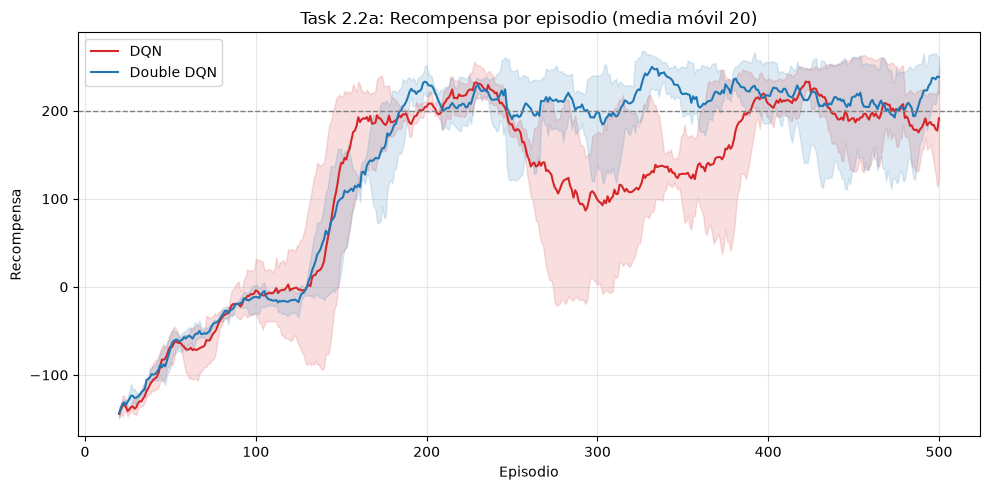

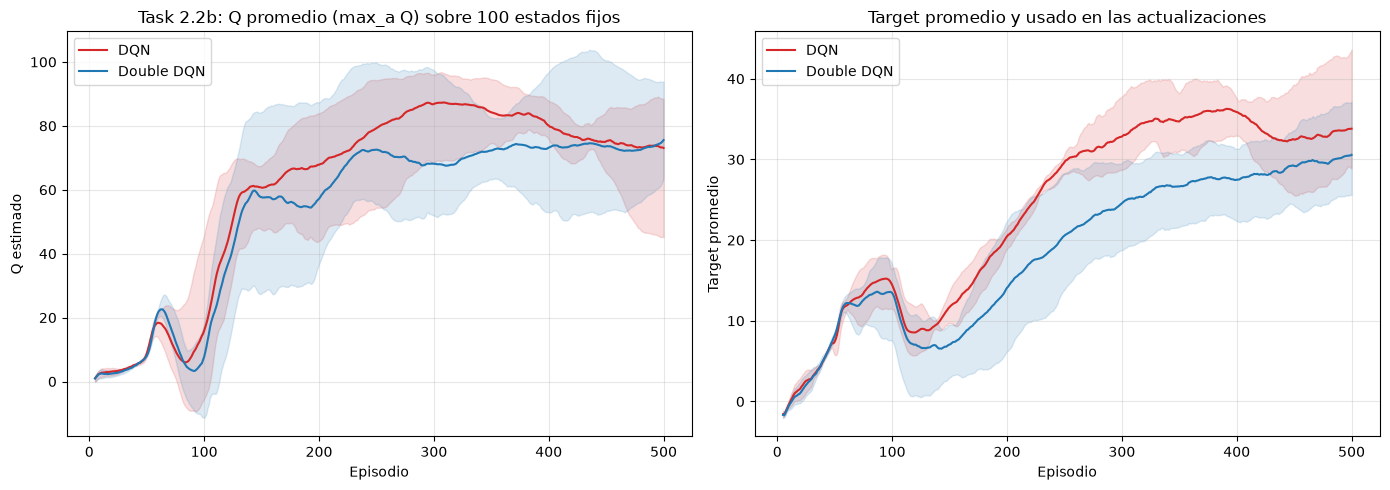

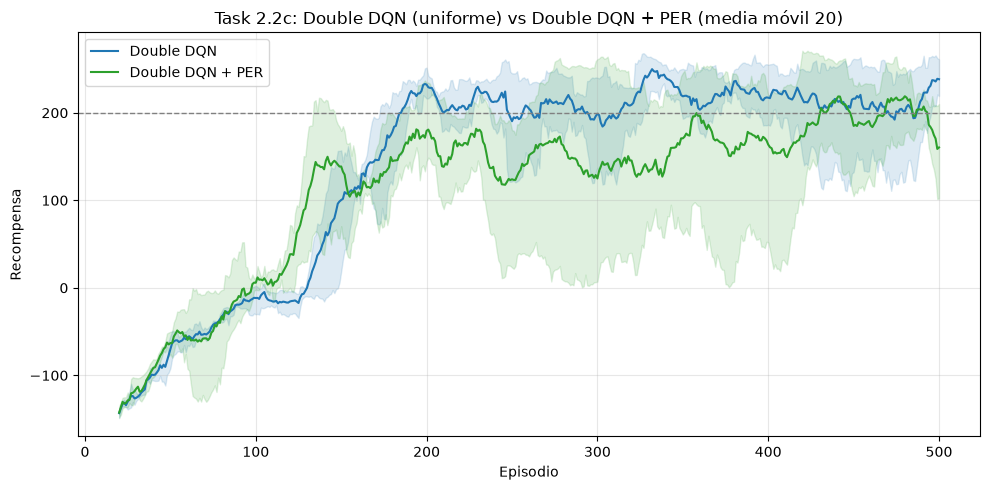

In [6]:
# ---------------------------------------------------------
# 7. Gráficas (media entre semillas; la banda sombreada es min-max entre semillas)
# ---------------------------------------------------------
COLORS = {'DQN': '#d62728', 'Double DQN': '#1f77b4', 'Double DQN + PER': '#2ca02c'}

def moving_average(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')

def plot_metric(ax, names, key, smooth=20, title='', ylabel=''):
    for name in names:
        curves = np.array([moving_average(h[key], smooth) for h in results[name]])
        x = np.arange(smooth, smooth + curves.shape[1])
        ax.plot(x, curves.mean(0), color=COLORS[name], label=name)
        ax.fill_between(x, curves.min(0), curves.max(0), color=COLORS[name], alpha=0.15)
    ax.set_title(title); ax.set_xlabel('Episodio'); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3); ax.legend()

# Task 2.2a: recompensa (media móvil 20) DQN vs Double DQN
fig, ax = plt.subplots(figsize=(10, 5))
plot_metric(ax, ['DQN', 'Double DQN'], 'reward', title='Task 2.2a: Recompensa por episodio (media móvil 20)',
            ylabel='Recompensa')
ax.axhline(200, color='gray', ls='--', lw=1)
plt.tight_layout(); plt.show()

# Task 2.2b: Q promedio sobre 100 estados fijos y target promedio de las actualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_metric(axes[0], ['DQN', 'Double DQN'], 'q', smooth=5,
            title='Task 2.2b: Q promedio (max_a Q) sobre 100 estados fijos', ylabel='Q estimado')
plot_metric(axes[1], ['DQN', 'Double DQN'], 'target', smooth=5,
            title='Target promedio y usado en las actualizaciones', ylabel='Target promedio')
plt.tight_layout(); plt.show()

# Task 2.2c: Double DQN uniforme vs Double DQN + PER
fig, ax = plt.subplots(figsize=(10, 5))
plot_metric(ax, ['Double DQN', 'Double DQN + PER'], 'reward',
            title='Task 2.2c: Double DQN (uniforme) vs Double DQN + PER (media móvil 20)', ylabel='Recompensa')
ax.axhline(200, color='gray', ls='--', lw=1)
plt.tight_layout(); plt.show()

In [7]:
# ---------------------------------------------------------
# 8. Resumen numérico (evidencia para las respuestas de la Task 2.2 y el dictamen)
# ---------------------------------------------------------
def first_episode_reaching(rewards, threshold, w=20):
    ma = moving_average(rewards, w)
    hit = np.where(ma >= threshold)[0]
    return int(hit[0] + w) if len(hit) else None

def fmt_eps(values):
    reached = [v for v in values if v is not None]
    if not reached:
        return 'nunca'
    return f"{np.mean(reached):.0f} ({len(reached)}/{len(values)} semillas)"

rows = []
for name, runs in results.items():
    rows.append({
        'Algoritmo': name,
        'Ep. media20 >= 0': fmt_eps([first_episode_reaching(h['reward'], 0) for h in runs]),
        'Ep. media20 >= 100': fmt_eps([first_episode_reaching(h['reward'], 100) for h in runs]),
        'Ep. media20 >= 200': fmt_eps([first_episode_reaching(h['reward'], 200) for h in runs]),
        'Recompensa ep. 1-150': f"{np.mean([h['reward'][:150].mean() for h in runs]):.1f}",
        'Recompensa ep. 151-300': f"{np.mean([h['reward'][150:300].mean() for h in runs]):.1f}",
        'Recompensa últimos 100': f"{np.mean([h['reward'][-100:].mean() for h in runs]):.1f}",
        'Q prom. últimos 100': f"{np.mean([h['q'][-100:].mean() for h in runs]):.1f}",
        'Target prom. últimos 100': f"{np.mean([np.nanmean(h['target'][-100:]) for h in runs]):.1f}",
    })

header = list(rows[0].keys())
widths = [max(len(h), *(len(r[h]) for r in rows)) for h in header]
print(' | '.join(h.ljust(w) for h, w in zip(header, widths)))
print('-+-'.join('-' * w for w in widths))
for r in rows:
    print(' | '.join(r[h].ljust(w) for h, w in zip(header, widths)))

# Diferencia Q(DQN) - Q(Double DQN) sobre los mismos 100 estados, por semilla
gap = [results['DQN'][i]['q'][-100:].mean() - results['Double DQN'][i]['q'][-100:].mean() for i in range(len(SEEDS))]
print('\nQ(DQN) - Q(Double DQN), últimos 100 episodios, por semilla:', [f'{g:.2f}' for g in gap])

Algoritmo        | Ep. media20 >= 0   | Ep. media20 >= 100 | Ep. media20 >= 200 | Recompensa ep. 1-150 | Recompensa ep. 151-300 | Recompensa últimos 100 | Q prom. últimos 100 | Target prom. últimos 100
-----------------+--------------------+--------------------+--------------------+----------------------+------------------------+------------------------+---------------------+-------------------------
DQN              | 116 (3/3 semillas) | 145 (3/3 semillas) | 164 (3/3 semillas) | -30.7                | 170.7                  | 199.7                  | 75.2                | 33.3                    
Double DQN       | 111 (3/3 semillas) | 148 (3/3 semillas) | 180 (3/3 semillas) | -34.3                | 201.5                  | 216.1                  | 73.5                | 29.1                    
Double DQN + PER | 94 (3/3 semillas)  | 140 (3/3 semillas) | 182 (2/3 semillas) | -10.7                | 146.3                  | 190.7                  | 70.2                | 35.3           

***
### Task 2.2: Respuestas basadas en los resultados

*Todas las cifras provienen de la tabla y las gráficas anteriores: 500 episodios, 3 semillas (42, 43, 44) por algoritmo, curvas promediadas entre semillas con banda min–max.*

**Resumen de resultados** (promedio de 3 semillas; "Ep. ≥ X" = primer episodio en que la media móvil de 20 alcanza X):

| Algoritmo | Ep. ≥ 0 | Ep. ≥ 100 | Ep. ≥ 200 | Recompensa ep. 1–150 | Recompensa ep. 151–300 | Recompensa últimos 100 | Q prom. últimos 100 | Target prom. últimos 100 |
|---|---|---|---|---|---|---|---|---|
| DQN | 116 (3/3) | 145 (3/3) | 164 (3/3) | −30.7 | 170.7 | 199.7 | 75.2 | 33.3 |
| Double DQN | 111 (3/3) | 148 (3/3) | 180 (3/3) | −34.3 | **201.5** | **216.1** | 73.5 | 29.1 |
| Double DQN + PER | **94** (3/3) | **140** (3/3) | 182 (2/3) | **−10.7** | 146.3 | 190.7 | 70.2 | 35.3 |

**a. Convergencia y recompensa final (DQN vs Double DQN):**
En la fase inicial ambos algoritmos son prácticamente indistinguibles: la media móvil de 20 cruza 0 en el episodio ~116 (DQN) y ~111 (Double DQN), y cruza 200 en el ~164 (DQN) y ~180 (Double DQN). Es decir, **DQN llega a 200 unos episodios antes, pero no es una diferencia significativa** dado el ancho de las bandas entre semillas.
La diferencia real aparece después: **DQN sufre un colapso de desempeño entre los episodios ~250 y ~380** (la media cae hasta ~90, y en alguna semilla por debajo de 0), mientras que Double DQN se mantiene alrededor de 200–240. Por eso Double DQN obtiene mayor recompensa en la fase media (episodios 151–300: **201.5 vs 170.7**) y mayor recompensa final (últimos 100 episodios: **216.1 vs 199.7**).
Esto coincide con lo esperado teóricamente, aunque con un matiz: la teoría no dice que Double DQN aprenda *más rápido*, sino que sus targets son menos sesgados y por tanto el aprendizaje es **más estable**. Eso es exactamente lo que se observa: el colapso de DQN coincide con el periodo en que su target promedio se separa más del de Double DQN (inciso b).

**b. Valor Q promedio y detección de sobreestimación:**
El patrón **se observa claramente en el target promedio** usado en las actualizaciones: a partir del episodio ~150 el target de DQN es sistemáticamente mayor que el de Double DQN (≈33–36 vs ≈25–30, y **33.3 vs 29.1** en los últimos 100 episodios). En el Q estimado sobre los 100 estados fijos el patrón **se observa sólo parcialmente**: entre los episodios ~200 y ~420 la curva de DQN está por encima (pico ≈87 vs ≈70), pero al final ambas convergen (≈75.2 vs 73.5) y por semilla la diferencia Q(DQN) − Q(DDQN) no tiene signo consistente (+28.7, −20.7, −3.0).
Por qué la sobreestimación no es tan visible en este entorno:
1. **Sólo 4 acciones:** el sesgo del operador `max` crece con el número de acciones; con 4 es pequeño.
2. **Recompensa densa:** LunarLander da recompensa en cada paso (shaping por distancia, velocidad y ángulo), lo que ancla los valores Q y limita la acumulación de sesgo por bootstrap.
3. **Los estados fijos provienen de una política aleatoria**, no de la distribución de estados que visita la política aprendida; sobre esos estados la sobreestimación en la zona que realmente se entrena se diluye. El target, en cambio, se calcula sobre transiciones del buffer y por eso muestra el sesgo con más claridad.
4. **Varianza entre semillas:** las bandas se solapan casi todo el tiempo; con 3 semillas la señal es real en el target pero ruidosa en Q.

**c. Double DQN con PER (α = 0.6, β: 0.4 → 1.0) vs muestreo uniforme:**
La diferencia es **más visible en la fase inicial de aprendizaje (episodios ~60–150)**, justo cuando el agente empieza a encontrar sus primeros aterrizajes: con PER la media móvil cruza 0 en el episodio **~94 vs ~111**, y la recompensa media de los episodios 1–150 es **−10.7 vs −34.3**. Las transiciones con error TD grande (choques de −100 y los primeros aterrizajes de +100) se repasan mucho más seguido, lo que acelera esa primera fase.
Sin embargo, **en la fase media y final PER fue peor y menos estable** en nuestros experimentos: recompensa en episodios 151–300 de **146.3 vs 201.5**, últimos 100 episodios **190.7 vs 216.1**, y sólo 2 de 3 semillas mantuvieron la media ≥ 200 (la semilla 44 terminó en ~102). Una explicación razonable es que, una vez que la política ya es buena, PER sigue sobre-muestreando las pocas transiciones con error alto (aumentando la varianza de los gradientes), y que usamos el mismo learning rate que en el caso uniforme, cuando Schaul et al. (2016) recomiendan reducirlo al usar PER. Con más ajuste de hiperparámetros la ventaja final probablemente se recupera, pero **la evidencia de este experimento apoya que PER acelera la fase temprana, no que mejore el desempeño asintótico**.

**d. ¿PER sería más o menos beneficioso en detección de intrusiones?**
**Más beneficioso**, y nuestros propios resultados lo sugieren. En LunarLander los eventos "críticos" (aterrizar o estrellarse) ocurren en *cada* episodio, así que el buffer uniforme ya contiene muchos de ellos; por eso la ventaja de PER se limitó a la fase en que los aterrizajes exitosos todavía eran raros (episodios ~60–150) y desapareció cuando dejaron de serlo. En detección de intrusiones los ataques son < 0.1% del tráfico (Task 1.1c): con muestreo uniforme un minibatch de 64 contendría una intrusión en promedio sólo una vez cada ~16 minibatches, es decir, el agente estaría **permanentemente** en el régimen de "evento raro" en el que PER mostró su ventaja en nuestro experimento. Además, cada intrusión mal clasificada produce un error TD grande (penalización de −100 en nuestra función de recompensa), que es precisamente la señal que PER usa para priorizar.
La advertencia que también sale de nuestros experimentos es que PER introdujo **inestabilidad en la fase tardía**; en producción habría que compensarla con un learning rate menor, β llegando a 1.0 para corregir completamente el sesgo del muestreo, y validación con varias semillas.

***
### Task 2.3: Investigación y Dictamen Técnico

**a. Investigación bibliográfica**

*Paper:* D. Fahrmann, N. Jorek, N. Damer, F. Kirchbuchner y A. Kuijper, "Double Deep Q-Learning With Prioritized Experience Replay for Anomaly Detection in Smart Environments", *IEEE Access*, vol. 10, pp. 60836–60848, 2022. DOI: [10.1109/ACCESS.2022.3179720](https://doi.org/10.1109/ACCESS.2022.3179720).

*Problema:* Detección de anomalías en entornos inteligentes, donde los eventos a detectar son **raros y críticos para la seguridad**, tanto de personas (p. ej. una caída) como de infraestructura (p. ej. accesos no autorizados a instalaciones protegidas). Los autores señalan que los datos de sensores son complejos y cambiantes, y que los métodos existentes suelen ser específicos del dominio y dependen de supuestos sesgados sobre los datos.

*Variante y justificación:* Formulan la detección como un problema de decisión y usan **Double DQN**, de modo que el agente aprende directamente una función de decisión sobre series de tiempo multivariadas. Como el énfasis está en clasificar eventos raros, **extienden DDQN con Prioritized Experience Replay**, para que las pocas transiciones anómalas (con error TD alto) se repasen más seguido que las normales.

*Resultados principales:* Evaluado en conjuntos de datos públicos reales de detección de caídas y de ocupación, el detector obtiene un desempeño **comparable al de trabajos previos**, y la extensión con PER **aumenta el desempeño de detección** respecto a DDQN sin PER. Como ventajas adicionales, el enfoque se adapta a distintos entornos y permite aprendizaje en línea.

*Reflexión respecto a la Task 1:* El trabajo ataca directamente dos de las limitaciones que identificamos: la **sobreestimación** (Task 1.2), usando DDQN, y la **rareza de los eventos críticos** (Task 1.1c), usando PER; su conclusión de que PER mejora la detección de eventos raros es consistente con nuestra ganancia temprana con PER en LunarLander. Quedan abiertas otras limitaciones: (1) el dominio no es tráfico de red y no hay un **adversario** que adapte su comportamiento para evadir al detector; (2) el desempeño es "comparable" y no superior al estado del arte, así que la ventaja de RL está en la adaptabilidad y el aprendizaje en línea más que en la precisión; y (3) el diseño de la recompensa frente al costo asimétrico entre falsos positivos y falsos negativos (Task 1.1d) sigue siendo una decisión de diseño que el algoritmo por sí solo no resuelve.

**b. Dictamen técnico a la Dirección de Ciberseguridad**

Recomendamos **proceder con Deep RL para el sistema de detección de intrusiones usando Double DQN como algoritmo base, con Prioritized Experience Replay ajustado**, y descartar DQN estándar. La recomendación se apoya en nuestra validación en LunarLander con 3 semillas por algoritmo: DQN estándar alcanzó un buen desempeño pero **colapsó a mitad del entrenamiento** (su recompensa media cayó de ~200 a ~90 entre los episodios 250 y 380), en el mismo periodo en que sus targets eran sistemáticamente más altos que los de Double DQN (≈35 vs ≈27), lo que es consistente con la sobreestimación. En un IDS, un colapso así equivale a semanas de bloqueos erróneos o de ataques ignorados. Double DQN, en cambio, se mantuvo estable y terminó con mayor recompensa (216 vs 200 en los últimos 100 episodios). PER aceleró el aprendizaje en la fase en que los eventos exitosos eran raros (−11 vs −34 de recompensa media en los primeros 150 episodios), que es la condición permanente de un IDS con < 0.1% de intrusiones; sin embargo, en nuestros experimentos también **aumentó la inestabilidad en la fase tardía**, por lo que no debe adoptarse con la configuración por defecto. Antes de un despliegue en producción serían necesarios: (1) entrenar y evaluar sobre tráfico real etiquetado (p. ej. CIC-IDS2017 o capturas propias), midiendo tasa de detección y tasa de falsos positivos frente al 8% del sistema actual; (2) ajustar la función de recompensa asimétrica de la Task 1.1d y los hiperparámetros de PER (learning rate menor, calendario de β), validando con varias semillas; (3) operar un periodo en **modo sombra** o "solo alerta", con las acciones "bloquear" y "aislar" sujetas a aprobación humana; y (4) monitorear en producción el Q promedio y el target promedio sobre un conjunto fijo de estados, como hicimos aquí, para detectar sobreestimación o deriva antes de que afecte la operación.